# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [7]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [8]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [9]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [10]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_725/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [11]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [12]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

In [19]:
# Atividade 3: listas para guardar a evolução dos pesos
w0_list = []
w1_list = []

num_epochs = 100
learning_rate = 0.5

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    #loss cálculo da função de perda
    loss = torch.mean((y_pred - target) ** 2)

    # backward propagation - cálculo gradient
    loss.backward()

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # Guardar evolução dos pesos a cada época ← NOVO
    w0_list.append(model.weight.data[0, 0].item())
    w1_list.append(model.weight.data[0, 1].item())

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    if (epoch + 1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'.format(epoch + 1, num_epochs, loss.data))

Epoch[20/100], loss: 0.021170
Epoch[40/100], loss: 0.021169
Epoch[60/100], loss: 0.021169
Epoch[80/100], loss: 0.021169
Epoch[100/100], loss: 0.021169


## Avaliação

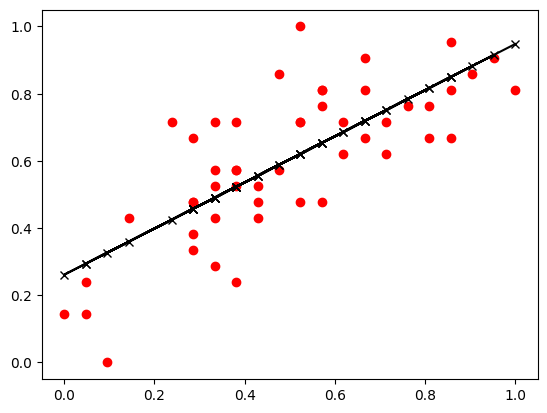

In [20]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

In [21]:
# Atividade 2: Perda (MSE) com os pesos já treinados
y_pred_trained = model(x_train_bias)
loss_trained = torch.mean((y_pred_trained - y_train) ** 2)
print(f'Perda (MSE) com pesos treinados: {loss_trained.item():.6f}')

Perda (MSE) com pesos treinados: 0.021169


### Acessando os parâmetros

In [22]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2614, 0.6864]]))])

### Parâmetros ótimos, solução analítica

In [23]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   
      - No laço de treinamento, loss é um tensor com grafo computacional — o PyTorch rastreia todas as operações feitas sobre ele para poder calcular os gradientes via loss.backward(). O atributo .data acessa o valor numérico puro do tensor, sem o grafo de autograd. Usar loss.data (ou loss.item() na forma mais moderna) é necessário porque:
        1. Imprimir o tensor completo mostraria informações extras do grafo além do número.
        2. Operar sobre o tensor com grafo ativo pode acumular histórico desnecessário e aumentar o consumo de memória.

        Resumindo: .data "desconecta" o tensor do grafo e devolve só o escalar numérico.

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

In [24]:
# Atividade 2: Perda (MSE) com os pesos já treinados
y_pred_trained = model(x_train_bias)
loss_trained = torch.mean((y_pred_trained - y_train) ** 2)
print(f'Perda (MSE) com pesos treinados: {loss_trained.item():.6f}')

Perda (MSE) com pesos treinados: 0.021169


- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

      - Código da célula do laço de treinamento alterado para a primeira parte do exercício, e célula de códgo adicionada para a execução da segunda parte do exercício

## Ploting vectors

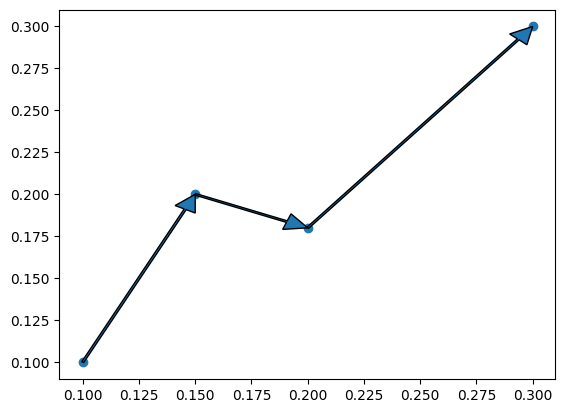

In [25]:
# Exemplo
w0_list = [0.1, 0.15, 0.2, 0.3]
w1_list = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

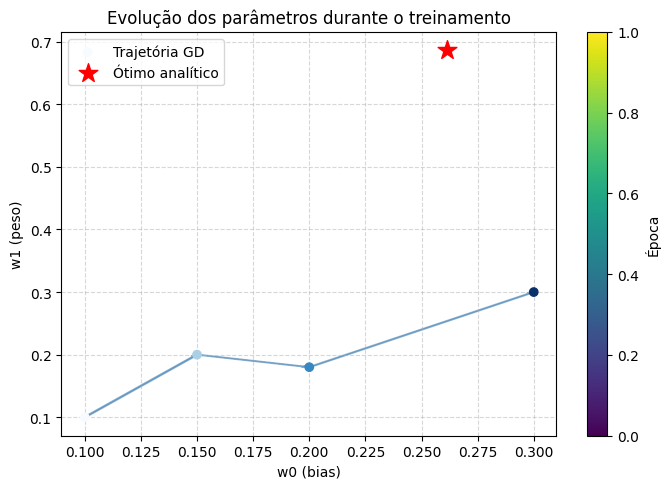

In [26]:
# Atividade 3: scatter plot da trajetória dos pesos + solução analítica
plt.figure(figsize=(7, 5))
plt.scatter(w0_list, w1_list, c=range(len(w0_list)),
            cmap='Blues', zorder=3, label='Trajetória GD')

# Setas mostrando a direção de atualização
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0 - w0_old, w1 - w1_old,
                  head_length=0.003, head_width=0.003, shape='full',
                  length_includes_head=True, color='steelblue', alpha=0.6)
    w0_old, w1_old = w0, w1

# Solução analítica (calculada anteriormente na célula w_opt)
w_opt_vals = torch.t(w_opt).squeeze()
plt.scatter(w_opt_vals[0].item(), w_opt_vals[1].item(),
            color='red', marker='*', s=200, zorder=5, label='Ótimo analítico')

plt.xlabel('w0 (bias)')
plt.ylabel('w1 (peso)')
plt.title('Evolução dos parâmetros durante o treinamento')
plt.colorbar(label='Época')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Aprendizados

Com esse exercício aprendi que:

- O PyTorch calcula o gradiente automaticamente com loss.backward(), sem precisar derivar na mão como fizemos no NumPy. Isso facilita muito a vida em redes mais complexas.
- O .data serve para acessar só o valor numérico do tensor, sem o grafo de gradientes que o PyTorch carrega junto. Sem ele, o print traria informações desnecessárias do grafo.
- É obrigatório zerar o gradiente a cada época com .zero_(), porque o PyTorch acumula os gradientes por padrão. Esquecer isso dá resultado errado sem nenhum aviso.
- O nn.Linear já encapsula os pesos e o forward da camada, o que é mais organizado do que gerenciar os tensores manualmente como fizemos antes.
- Plotando a trajetória dos pesos durante o treinamento dá pra ver que o gradiente descendente não vai direto ao ponto ótimo, ele vai se aproximando aos poucos. Comparando com a solução analítica (que dá o mínimo exato), os pesos treinados chegam muito perto, o que confirma que o método funcionou.